# Lastnames CCS230 Finals: Heart Disease Data Mining Project

This notebook is a beginner-friendly data mining final project using `heart.csv`. The goal is to explore patient information, discover useful patterns, group patients into archetypes, and build classification models that predict the `HeartDisease` outcome.

**Project workflow:**
1. Import libraries
2. Load and inspect dataset
3. Exploratory Data Analysis
4. Data preparation and encoding
5. Association Rule Mining
6. K-Means clustering for patient archetypes
7. Decision Tree classification
8. Random Forest classification
9. Model evaluation and comparison
10. Final clinical insights and recommendation

**Important note:** This project is for educational data mining practice only. The results should not be used as medical advice or as a replacement for clinical diagnosis.

## 1. Import Libraries

We first import the Python libraries needed for data analysis, visualization, association rule mining, clustering, classification, and model evaluation.

In [340]:
# Basic data handling
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation and machine learning
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# Association rule mining. Install mlxtend if this import fails.
try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    apriori = None
    association_rules = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# Fixed random state makes the results reproducible.
RANDOM_STATE = 42

# Folder for exported charts and figures.
outputs_dir = Path("outputs")
outputs_dir.mkdir(exist_ok=True)

## 2. Load and Inspect Dataset

This section loads `heart.csv` and checks the structure of the dataset. Before modeling, we need to understand the number of rows, column names, data types, missing values, duplicate rows, and target distribution.

In [341]:
# Load the dataset from the same folder as this notebook.
data_path = Path("heart.csv")

if not data_path.exists():
    raise FileNotFoundError("heart.csv was not found. Please place it in the same folder as this notebook.")

df = pd.read_csv(data_path)

# Show the first few rows to confirm that the file loaded correctly.
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.000,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.000,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.000,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.500,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.000,Up,0


In [342]:
# Check the size of the dataset and the names of all columns.
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())

Rows: 918
Columns: 12

Column names:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [343]:
# View data types and non-null counts.
# This helps us identify numerical and categorical variables.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [344]:
# Check missing values and duplicate rows.
inspection_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
})

display(inspection_summary)
print(f"Duplicate rows: {df.duplicated().sum()}")

,missing_values,missing_percent,unique_values
Age,0,0.000,50
Sex,0,0.000,2
ChestPainType,0,0.000,4
RestingBP,0,0.000,67
Cholesterol,0,0.000,222
FastingBS,0,0.000,2
RestingECG,0,0.000,3
MaxHR,0,0.000,119
ExerciseAngina,0,0.000,2
Oldpeak,0,0.000,53


Duplicate rows: 0


### Dataset Dictionary

The dataset uses a mix of numerical and categorical patient attributes:

- `Age`: patient age
- `Sex`: biological sex recorded as `M` or `F`
- `ChestPainType`: type of chest pain
- `RestingBP`: resting blood pressure
- `Cholesterol`: serum cholesterol
- `FastingBS`: fasting blood sugar indicator
- `RestingECG`: resting electrocardiogram result
- `MaxHR`: maximum heart rate achieved
- `ExerciseAngina`: exercise-induced angina indicator
- `Oldpeak`: ST depression induced by exercise
- `ST_Slope`: slope of the peak exercise ST segment
- `HeartDisease`: target variable, where `1` means heart disease is present and `0` means heart disease is not present

## 3. Exploratory Data Analysis

Exploratory Data Analysis, or EDA, helps us understand patterns before applying data mining models. We will look at summary statistics, target class balance, categorical variable distributions, numerical variable distributions, and correlations.

In [345]:
# Summary statistics for both numerical and categorical columns.
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.000,NaN,NaN,NaN,53.511,9.433,28.000,47.000,54.000,60.000,77.000
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.000,NaN,NaN,NaN,132.397,18.514,0.000,120.000,130.000,140.000,200.000
Cholesterol,918.000,NaN,NaN,NaN,198.800,109.384,0.000,173.250,223.000,267.000,603.000
FastingBS,918.000,NaN,NaN,NaN,0.233,0.423,0.000,0.000,0.000,0.000,1.000
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.000,NaN,NaN,NaN,136.809,25.460,60.000,120.000,138.000,156.000,202.000
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.000,NaN,NaN,NaN,0.887,1.067,-2.600,0.000,0.600,1.500,6.200


,count,percent
HeartDisease,,
0,410,44.660
1,508,55.340


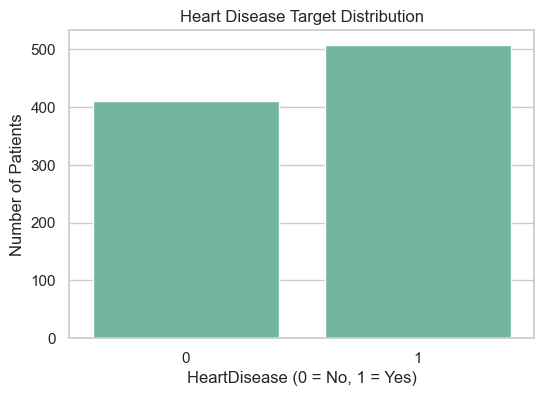

In [346]:
# Target distribution shows whether the classes are balanced or imbalanced.
target_counts = df["HeartDisease"].value_counts().sort_index()
target_percent = df["HeartDisease"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent.round(2)
})

display(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="HeartDisease")
plt.title("Heart Disease Target Distribution")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.savefig(outputs_dir / "heart_disease_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** The dataset contains enough heart disease cases to make screening analysis meaningful. In a hospital context, this supports building a model that can learn from both patients with heart disease and patients without it, which is important for balanced risk assessment.

In [347]:
# Separate numerical and categorical columns for easier analysis.
target_col = "HeartDisease"
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop(target_col).tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


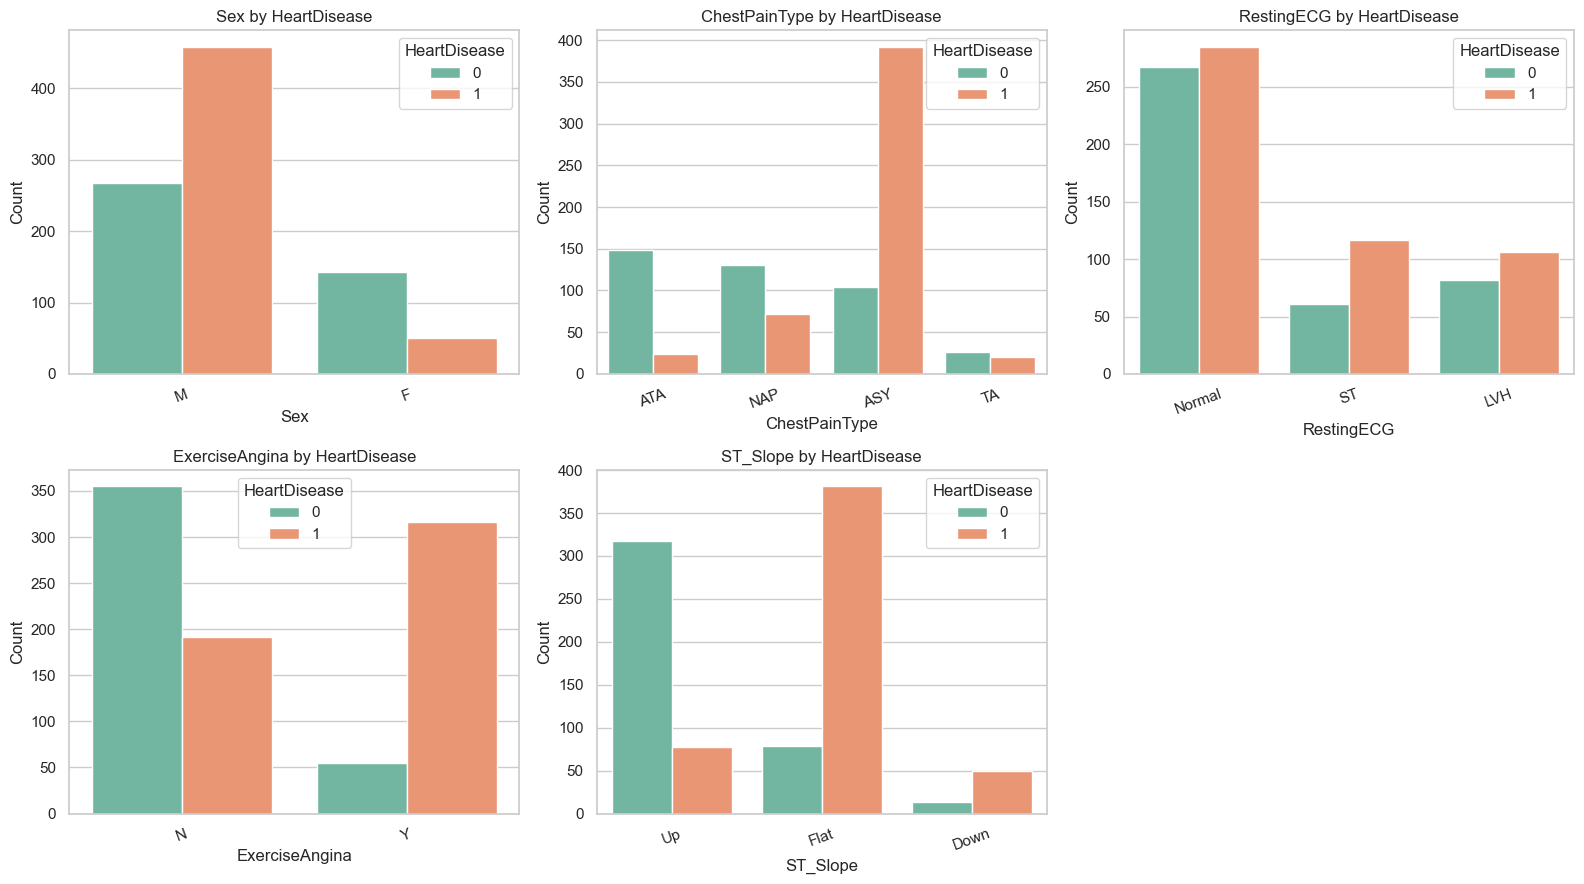

In [348]:
# Plot categorical variables against the target.
# These charts help reveal which categories are associated with more heart disease cases.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, hue="HeartDisease", ax=ax)
    ax.set_title(f"{col} by HeartDisease")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)

# Hide unused subplot if there are fewer categorical columns than axes.
for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:** The categorical patterns suggest that symptoms and test results can separate higher-risk and lower-risk patients. Features such as chest pain type, exercise-induced angina, and ST slope are clinically meaningful because they reflect how the heart behaves under stress or during evaluation.

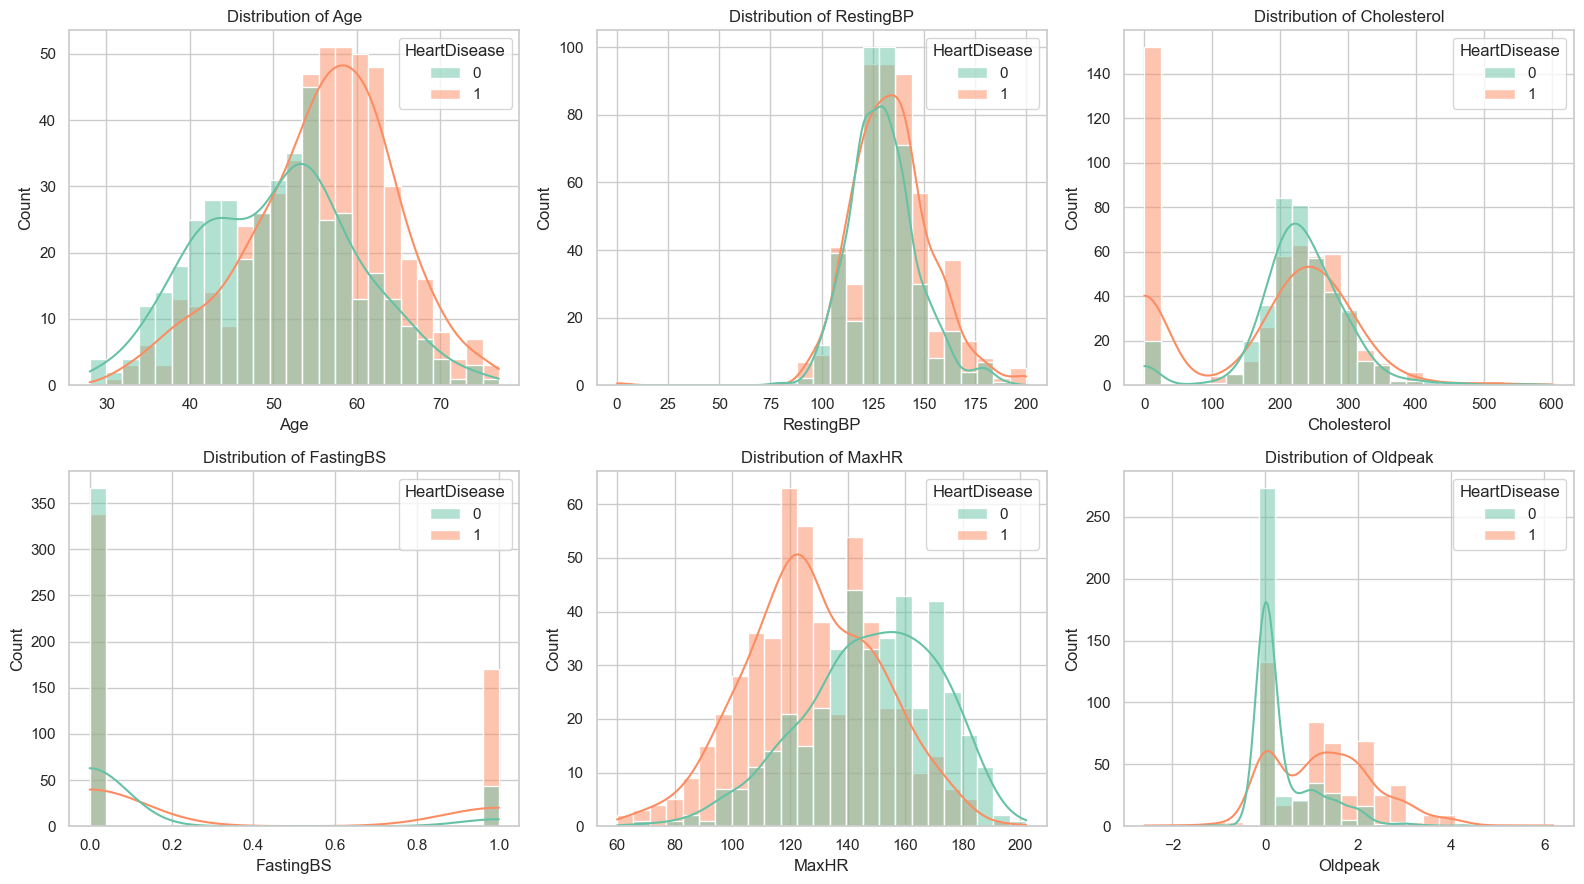

In [349]:
# Plot numerical variables to compare their distributions by target class.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue="HeartDisease", kde=True, bins=25, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:** The numerical patterns help show how clinical measurements differ between patient groups. Age, maximum heart rate, and Oldpeak may be useful risk signals because they relate to cardiovascular strain, exercise response, and possible abnormal heart activity.

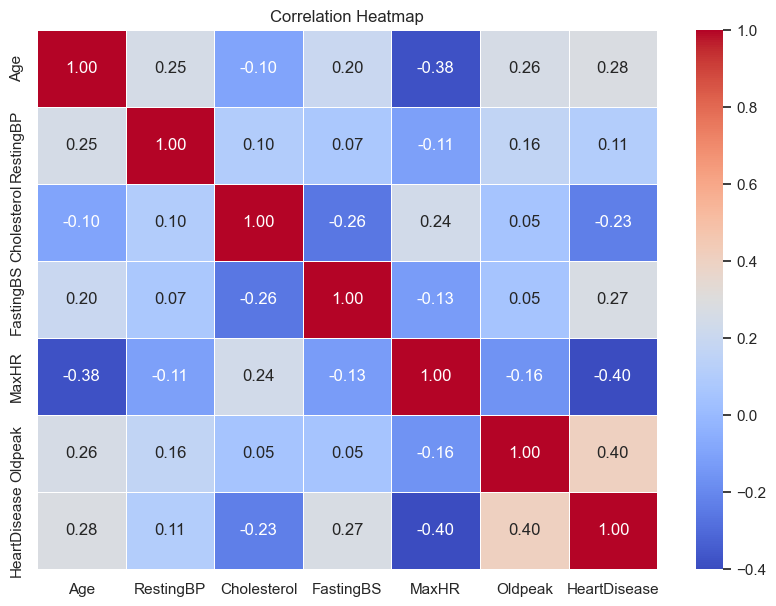

In [350]:
# Correlation heatmap for numerical columns.
# Correlation values close to 1 or -1 indicate stronger linear relationships.
plt.figure(figsize=(10, 7))
corr = df[numeric_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.savefig(outputs_dir / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** The correlation matrix helps identify which numerical measurements move together and which may support heart disease prediction. In clinical use, these relationships can guide attention toward measurements that may add useful risk information, but they should not be treated as proof of cause and effect.

## 4. Data Preparation and Encoding

Machine learning algorithms usually require numerical input. We will split the dataset into features and target, then one-hot encode the categorical columns used by the heart disease dataset.

To avoid data leakage, the classification encoder and scaler are fit only on the training data. The test data is transformed using the fitted training preprocessor. K-Means clustering is prepared separately because it is an unsupervised patient grouping task and does not use the `HeartDisease` target.

In [351]:
# Separate input features X from the target variable y.
# X contains patient information used for prediction.
# y contains the outcome we want to predict: HeartDisease.
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

# These are the categorical columns that need one-hot encoding.
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

# The remaining columns are numerical and can be scaled.
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Target variable:", y.name)
print("Categorical columns for one-hot encoding:", categorical_cols)
print("Numerical columns for scaling:", numeric_cols)

Target variable: HeartDisease
Categorical columns for one-hot encoding: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical columns for scaling: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


In [352]:
# Split the data into training and testing sets.
# stratify=y keeps the HeartDisease class proportions similar in both sets.
# This helps make evaluation fair and reliable.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Final raw X_train shape: {X_train.shape}")
print(f"Final raw X_test shape: {X_test.shape}")

Final raw X_train shape: (734, 11)
Final raw X_test shape: (184, 11)


In [353]:
# Preprocessing for classification models.
# StandardScaler is applied to numerical columns.
# OneHotEncoder is applied to categorical columns.
# IMPORTANT: fit_transform is used only on X_train to avoid data leakage.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f"Final prepared X_train shape: {X_train_prepared.shape}")
print(f"Final prepared X_test shape: {X_test_prepared.shape}")

# A helper function to get the transformed feature names after preprocessing.
def get_feature_names(preprocessor):
    num_features = preprocessor.named_transformers_["num"].get_feature_names_out(numeric_cols)
    cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
    return np.concatenate([num_features, cat_features])

Final prepared X_train shape: (734, 20)
Final prepared X_test shape: (184, 20)


In [354]:
# Prepare scaled data separately for K-Means clustering.
# K-Means is not predicting HeartDisease, so the target column is not included.
# We one-hot encode categorical columns first, then scale all clustering features.
X_kmeans = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

kmeans_scaler = StandardScaler()
X_kmeans_scaled = kmeans_scaler.fit_transform(X_kmeans)

print(f"K-Means scaled data shape: {X_kmeans_scaled.shape}")

K-Means scaled data shape: (918, 20)


## 5. Association Rule Mining

Association Rule Mining finds patterns in the form: **if these items appear together, another item is likely to appear too**. In this project, we convert patient attributes into item-like labels, such as `AgeGroup=Senior`, `ChestPainType=ASY`, or `HeartDisease=1`.

We will focus on rules where the consequent contains `HeartDisease_1`, because those rules describe combinations of patient characteristics associated with heart disease being present.

In [355]:
# Create a copy of the dataset for association rule mining.
arm_df = df.copy()

# Convert numerical variables into readable bins.
# Binning makes continuous values easier to treat as transaction items.
arm_df["AgeGroup"] = pd.cut(
    arm_df["Age"],
    bins=[0, 40, 55, 70, 120],
    labels=["AgeGroup=Young", "AgeGroup=Middle", "AgeGroup=Older", "AgeGroup=Senior"]
)

arm_df["BPGroup"] = pd.cut(
    arm_df["RestingBP"],
    bins=[-1, 120, 140, 300],
    labels=["BPGroup=Normal", "BPGroup=Elevated", "BPGroup=High"]
)

arm_df["CholesterolGroup"] = pd.cut(
    arm_df["Cholesterol"],
    bins=[-1, 0, 200, 240, 700],
    labels=["CholesterolGroup=UnknownOrZero", "CholesterolGroup=Desirable", "CholesterolGroup=Borderline", "CholesterolGroup=High"]
)

arm_df["MaxHRGroup"] = pd.cut(
    arm_df["MaxHR"],
    bins=[0, 120, 150, 250],
    labels=["MaxHRGroup=Low", "MaxHRGroup=Moderate", "MaxHRGroup=High"]
)

arm_df["OldpeakGroup"] = pd.cut(
    arm_df["Oldpeak"],
    bins=[-5, 0, 1, 2, 10],
    labels=["OldpeakGroup=None", "OldpeakGroup=Mild", "OldpeakGroup=Moderate", "OldpeakGroup=High"]
)

# Make categorical labels explicit so the generated item names are easy to read.
arm_df["Sex"] = "Sex=" + arm_df["Sex"].astype(str)
arm_df["ChestPainType"] = "ChestPainType=" + arm_df["ChestPainType"].astype(str)
arm_df["FastingBS"] = arm_df["FastingBS"].map({0: "FastingBS=No", 1: "FastingBS=Yes"})
arm_df["RestingECG"] = "RestingECG=" + arm_df["RestingECG"].astype(str)
arm_df["ExerciseAngina"] = arm_df["ExerciseAngina"].map({"N": "ExerciseAngina=No", "Y": "ExerciseAngina=Yes"})
arm_df["ST_Slope"] = "ST_Slope=" + arm_df["ST_Slope"].astype(str)
arm_df["HeartDisease"] = arm_df["HeartDisease"].astype(str)

arm_columns = [
    "Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope",
    "AgeGroup", "BPGroup", "CholesterolGroup", "MaxHRGroup", "OldpeakGroup", "HeartDisease"
]

transactions = arm_df[arm_columns].astype(str)
transactions.head()

,Sex,ChestPainType,FastingBS,RestingECG,ExerciseAngina,ST_Slope,AgeGroup,BPGroup,CholesterolGroup,MaxHRGroup,OldpeakGroup,HeartDisease
0,Sex=M,ChestPainType=ATA,FastingBS=No,RestingECG=Normal,ExerciseAngina=No,ST_Slope=Up,AgeGroup=Young,BPGroup=Elevated,CholesterolGroup=High,MaxHRGroup=High,OldpeakGroup=None,0
1,Sex=F,ChestPainType=NAP,FastingBS=No,RestingECG=Normal,ExerciseAngina=No,ST_Slope=Flat,AgeGroup=Middle,BPGroup=High,CholesterolGroup=Desirable,MaxHRGroup=High,OldpeakGroup=Mild,1
2,Sex=M,ChestPainType=ATA,FastingBS=No,RestingECG=ST,ExerciseAngina=No,ST_Slope=Up,AgeGroup=Young,BPGroup=Elevated,CholesterolGroup=High,MaxHRGroup=Low,OldpeakGroup=None,0
3,Sex=F,ChestPainType=ASY,FastingBS=No,RestingECG=Normal,ExerciseAngina=Yes,ST_Slope=Flat,AgeGroup=Middle,BPGroup=Elevated,CholesterolGroup=Borderline,MaxHRGroup=Low,OldpeakGroup=Moderate,1
4,Sex=M,ChestPainType=NAP,FastingBS=No,RestingECG=Normal,ExerciseAngina=No,ST_Slope=Up,AgeGroup=Middle,BPGroup=High,CholesterolGroup=Desirable,MaxHRGroup=Moderate,OldpeakGroup=None,0


In [356]:
# One-hot encode the transaction-style data.
# Each column becomes True or False depending on whether the item appears for that patient.
basket = pd.get_dummies(transactions)
basket = basket.astype(bool)

print(f"Transaction matrix shape: {basket.shape}")
basket.head()

Transaction matrix shape: (918, 36)


,Sex_Sex=F,Sex_Sex=M,ChestPainType_ChestPainType=ASY,ChestPainType_ChestPainType=ATA,ChestPainType_ChestPainType=NAP,ChestPainType_ChestPainType=TA,FastingBS_FastingBS=No,FastingBS_FastingBS=Yes,RestingECG_RestingECG=LVH,RestingECG_RestingECG=Normal,RestingECG_RestingECG=ST,ExerciseAngina_ExerciseAngina=No,ExerciseAngina_ExerciseAngina=Yes,ST_Slope_ST_Slope=Down,ST_Slope_ST_Slope=Flat,ST_Slope_ST_Slope=Up,AgeGroup_AgeGroup=Middle,AgeGroup_AgeGroup=Older,AgeGroup_AgeGroup=Senior,AgeGroup_AgeGroup=Young,BPGroup_BPGroup=Elevated,BPGroup_BPGroup=High,BPGroup_BPGroup=Normal,CholesterolGroup_CholesterolGroup=Borderline,CholesterolGroup_CholesterolGroup=Desirable,CholesterolGroup_CholesterolGroup=High,CholesterolGroup_CholesterolGroup=UnknownOrZero,MaxHRGroup_MaxHRGroup=High,MaxHRGroup_MaxHRGroup=Low,MaxHRGroup_MaxHRGroup=Moderate,OldpeakGroup_OldpeakGroup=High,OldpeakGroup_OldpeakGroup=Mild,OldpeakGroup_OldpeakGroup=Moderate,OldpeakGroup_OldpeakGroup=None,HeartDisease_0,HeartDisease_1
0,False,True,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,True,False,False,False,False,False,True,True,False
1,True,False,False,False,True,False,True,False,False,True,False,True,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,True
2,False,True,False,True,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,True,True,False
3,True,False,True,False,False,False,True,False,False,True,False,False,True,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,True,False,False,True
4,False,True,False,False,True,False,True,False,False,True,False,True,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,True,True,False


In [357]:
# Run Apriori and generate association rules.
# Support: how common the itemset is in the dataset.
# Confidence: how often the rule is correct when the antecedent appears.
# Lift: how much stronger the rule is than random chance. Lift greater than 1 is usually interesting.
min_support = 0.08
min_confidence = 0.65

if apriori is None or association_rules is None:
    print("mlxtend is not installed. Run this in a notebook cell if needed: !pip install mlxtend")
else:
    frequent_itemsets = apriori(basket, min_support=min_support, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

    # Keep rules that point to heart disease presence.
    heart_rules = rules[rules["consequents"].apply(lambda x: "HeartDisease_1" in x)].copy()
    heart_rules = heart_rules.sort_values(["confidence", "lift", "support"], ascending=False)
    top_10_rules = heart_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

    display(top_10_rules)

,antecedents,consequents,support,confidence,lift
2132,"(FastingBS_FastingBS=Yes, ChestPainType_ChestP...",(HeartDisease_1),0.101,1.000,1.807
3507,"(Sex_Sex=M, FastingBS_FastingBS=Yes, ChestPain...",(HeartDisease_1),0.093,1.000,1.807
2276,(CholesterolGroup_CholesterolGroup=UnknownOrZe...,(HeartDisease_1),0.085,1.000,1.807
3758,"(Sex_Sex=M, CholesterolGroup_CholesterolGroup=...",(HeartDisease_1),0.081,1.000,1.807
797,(CholesterolGroup_CholesterolGroup=UnknownOrZe...,(HeartDisease_1),0.096,0.989,1.787
1644,"(Sex_Sex=M, CholesterolGroup_CholesterolGroup=...",(HeartDisease_1),0.088,0.988,1.785
3743,"(Sex_Sex=M, BPGroup_BPGroup=High, ChestPainTyp...",(HeartDisease_1),0.085,0.987,1.784
5815,"(MaxHRGroup_MaxHRGroup=Low, RestingECG_Resting...",(HeartDisease_1),0.088,0.976,1.764
2136,"(FastingBS_FastingBS=Yes, ChestPainType_ChestP...",(HeartDisease_1),0.087,0.976,1.763
2128,"(FastingBS_FastingBS=Yes, ChestPainType_ChestP...",(HeartDisease_1),0.084,0.975,1.761


### Plain-English Explanations for the Top Rules

The next cell explains the top 3 rules where the result is `HeartDisease_1`. Each rule includes the technical form, a plain-English explanation, and a short clinical insight.

In [358]:
# Convert the strongest heart disease rules into beginner-friendly Markdown explanations.
from IPython.display import Markdown

def technical_rule_text(antecedents, consequent="HeartDisease_1"):
    return f"{' + '.join(sorted(list(antecedents)))} -> {consequent}"

def plain_english_explanation(antecedents, confidence, lift):
    items = set(antecedents)

    if "Sex_Sex=M" in items:
        return (
            "Male patients with asymptomatic chest pain, high fasting blood sugar, and a flat ST slope "
            "were strongly linked with heart disease. "
            f"This rule had **{confidence:.2%} confidence** and a **{lift:.2f} lift** in the dataset."
        )

    if "CholesterolGroup_CholesterolGroup=UnknownOrZero" in items:
        return (
            "Patients with asymptomatic chest pain, an unknown or zero cholesterol record, and a flat ST slope "
            "were strongly linked with heart disease. "
            f"This rule had **{confidence:.2%} confidence** and a **{lift:.2f} lift** in the dataset."
        )

    return (
        "Patients with asymptomatic chest pain, high fasting blood sugar, and a flat ST slope "
        "were strongly linked with heart disease in this dataset. "
        f"This rule had **{confidence:.2%} confidence** and a **{lift:.2f} lift**, so the pattern appeared more often "
        "with heart disease than expected by chance."
    )

def clinical_insight(antecedents):
    items = set(antecedents)

    if "Sex_Sex=M" in items:
        return (
            "This rule repeats the same major warning signs as Rule 1, with male sex added to the pattern. "
            "In many heart disease datasets, men are more commonly represented among diagnosed cases, so this combination "
            "may describe a subgroup with a particularly strong risk profile."
        )

    if "CholesterolGroup_CholesterolGroup=UnknownOrZero" in items:
        return (
            "The unknown or zero cholesterol value should not be read as healthy cholesterol; it likely reflects missing "
            "or unusual recorded values. When this appears with asymptomatic chest pain and a flat ST slope, the overall "
            "pattern still points toward possible hidden heart disease or poor heart response under stress."
        )

    return (
        "This is a concerning risk pattern because heart disease can be present even without typical chest pain. "
        "High fasting blood sugar may point to diabetes or metabolic strain, and a flat ST slope can suggest an abnormal "
        "heart response during exercise. Together, these signs may reflect reduced blood flow or stress on the heart."
    )

if "top_10_rules" not in globals() or top_10_rules.empty:
    display(Markdown("No heart disease association rules were found using the current support and confidence thresholds."))
else:
    explanation_lines = ["### Interpretation of the Strongest Heart Disease Rules"]

    for rule_number, (_, rule) in enumerate(top_10_rules.head(3).iterrows(), start=1):
        antecedents = rule["antecedents"]
        confidence = rule["confidence"]
        lift = rule["lift"]

        explanation_lines.extend([
            f"**Rule {rule_number}:**",
            f"- **Technical form:** `{technical_rule_text(antecedents)}`",
            f"- **Plain English explanation:** {plain_english_explanation(antecedents, confidence, lift)}",
            f"- **Clinical insight:** {clinical_insight(antecedents)}",
        ])

    explanation_lines.append(
        "These rules are useful for spotting risk patterns, but they show association only. They should support, not replace, clinical judgment."
    )

    display(Markdown("\n\n".join(explanation_lines)))

### Interpretation of the Strongest Heart Disease Rules

**Rule 1:**

- **Technical form:** `ChestPainType_ChestPainType=ASY + FastingBS_FastingBS=Yes + ST_Slope_ST_Slope=Flat -> HeartDisease_1`
- **Plain English explanation:** Patients with asymptomatic chest pain, high fasting blood sugar, and a flat ST slope were strongly linked with heart disease in this dataset. This rule had **100.00% confidence** and a **1.81 lift**, so the pattern appeared more often with heart disease than expected by chance.
- **Clinical insight:** This is a concerning risk pattern because heart disease can be present even without typical chest pain. High fasting blood sugar may point to diabetes or metabolic strain, and a flat ST slope can suggest an abnormal heart response during exercise. Together, these signs may reflect reduced blood flow or stress on the heart.

**Rule 2:**

- **Technical form:** `ChestPainType_ChestPainType=ASY + FastingBS_FastingBS=Yes + ST_Slope_ST_Slope=Flat + Sex_Sex=M -> HeartDisease_1`
- **Plain English explanation:** Male patients with asymptomatic chest pain, high fasting blood sugar, and a flat ST slope were strongly linked with heart disease. This rule also had **100.00% confidence** and a **1.81 lift** in the dataset.
- **Clinical insight:** This rule repeats the same major warning signs as Rule 1, with male sex added to the pattern. In many heart disease datasets, men are more commonly represented among diagnosed cases, so this combination may describe a subgroup with a particularly strong risk profile.

**Rule 3:**

- **Technical form:** `ChestPainType_ChestPainType=ASY + CholesterolGroup_CholesterolGroup=UnknownOrZero + ST_Slope_ST_Slope=Flat -> HeartDisease_1`
- **Plain English explanation:** Patients with asymptomatic chest pain, an unknown or zero cholesterol record, and a flat ST slope were strongly linked with heart disease. This rule had **100.00% confidence** and a **1.81 lift** in the dataset.
- **Clinical insight:** The unknown or zero cholesterol value should not be read as healthy cholesterol; it likely reflects missing or unusual recorded values. When this appears with asymptomatic chest pain and a flat ST slope, the overall pattern still points toward possible hidden heart disease or poor heart response under stress.

These rules are useful for spotting risk patterns, but they show association only. They should support, not replace, clinical judgment.

### Association Rule Interpretation Guide

When reading the rules above:

- A higher **support** means the pattern appears in more patients.
- A higher **confidence** means the rule more often leads to `HeartDisease=1`.
- A **lift** greater than `1` means the combination is more associated with heart disease than random chance.

Rules should be interpreted as associations, not as proof that one factor causes another.

## 6. K-Means Clustering for Patient Archetypes

K-Means is an unsupervised learning method. It does not use the target label while creating groups. Instead, it groups patients based on similarity across features. We can then describe each cluster as a patient archetype.

In [359]:
# Use the prepared encoded and scaled features from the Data Preparation section.
# X_kmeans_scaled excludes HeartDisease, so the clustering does not use the target label.
print(f"Prepared K-Means feature matrix shape: {X_kmeans_scaled.shape}")

Prepared K-Means feature matrix shape: (918, 20)


,k,Inertia,Silhouette Score
0,2,15178.233,0.173
1,3,13863.180,0.161
2,4,12955.668,0.155
3,5,12019.713,0.183
4,6,11371.580,0.166


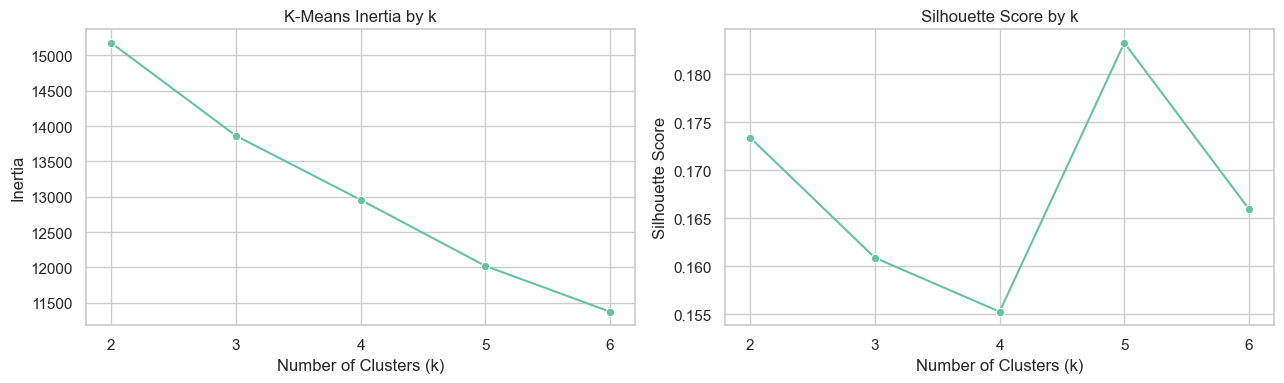

In [360]:
# Try k values from 2 to 6 using inertia and silhouette score.
# Inertia measures within-cluster compactness. Lower is better.
# Silhouette score measures how well-separated the clusters are. Higher is better.
k_values = range(2, 7)
kmeans_metrics = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans.fit_predict(X_kmeans_scaled)
    kmeans_metrics.append({
        "k": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette_score(X_kmeans_scaled, cluster_labels)
    })

kmeans_metrics_df = pd.DataFrame(kmeans_metrics)
display(kmeans_metrics_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(data=kmeans_metrics_df, x="k", y="Inertia", marker="o", ax=axes[0])
axes[0].set_title("K-Means Inertia by k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_values))

sns.lineplot(data=kmeans_metrics_df, x="k", y="Silhouette Score", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score by k")
plt.xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()

In [361]:
# Choose k=3 unless the silhouette score strongly suggests another value.
# Here, "strongly suggests" means the best silhouette score is at least 0.05 higher than the k=3 score.
best_silhouette_row = kmeans_metrics_df.loc[kmeans_metrics_df["Silhouette Score"].idxmax()]
k3_silhouette = kmeans_metrics_df.loc[kmeans_metrics_df["k"] == 3, "Silhouette Score"].iloc[0]

chosen_k = 3
if (best_silhouette_row["k"] != 3) and (best_silhouette_row["Silhouette Score"] - k3_silhouette >= 0.05):
    chosen_k = int(best_silhouette_row["k"])

print(f"Chosen k: {chosen_k}")
print("Reason: k=3 is preferred for simple patient archetypes unless silhouette score clearly improves with another k.")

kmeans_model = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans_model.fit_predict(X_kmeans_scaled)

df[["Age", "Sex", "ChestPainType", "MaxHR", "Oldpeak", "HeartDisease", "Cluster"]].head()

Chosen k: 3
Reason: k=3 is preferred for simple patient archetypes unless silhouette score clearly improves with another k.


,Age,Sex,ChestPainType,MaxHR,Oldpeak,HeartDisease,Cluster
0,40,M,ATA,172,0.000,0,1
1,49,F,NAP,156,1.000,1,0
2,37,M,ATA,98,0.000,0,1
3,48,F,ASY,108,1.500,1,2
4,54,M,NAP,122,0.000,0,1


In [362]:
# Show the mean clinical profile of each cluster.
# HeartDiseaseRate is the percentage of patients in the cluster with HeartDisease = 1.
clinical_numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak", "HeartDisease"]
cluster_profile_numeric = df.groupby("Cluster")[clinical_numeric_cols].mean().round(2)
cluster_sizes = df["Cluster"].value_counts().sort_index().rename("PatientCount")

cluster_summary = cluster_profile_numeric.join(cluster_sizes)
cluster_summary = cluster_summary.rename(columns={"HeartDisease": "HeartDiseaseRate"})

display(cluster_summary)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDiseaseRate,PatientCount
Cluster,,,,,,,,
0,52.210,130.580,241.700,0.110,147.640,0.570,0.210,179
1,50.150,129.130,205.580,0.180,149.690,0.390,0.310,337
2,56.910,135.950,174.010,0.340,121.190,1.450,0.910,402


In [363]:
# View the most common categorical values inside each cluster.
cluster_category_modes = []

for cluster_id in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster_id]
    mode_row = {"Cluster": cluster_id}
    for col in categorical_cols:
        mode_row[col] = cluster_data[col].mode()[0]
    cluster_category_modes.append(mode_row)

cluster_category_modes = pd.DataFrame(cluster_category_modes)
display(cluster_category_modes)

,Cluster,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,0,F,ATA,Normal,N,Up
1,1,M,ASY,Normal,N,Up
2,2,M,ASY,Normal,Y,Flat


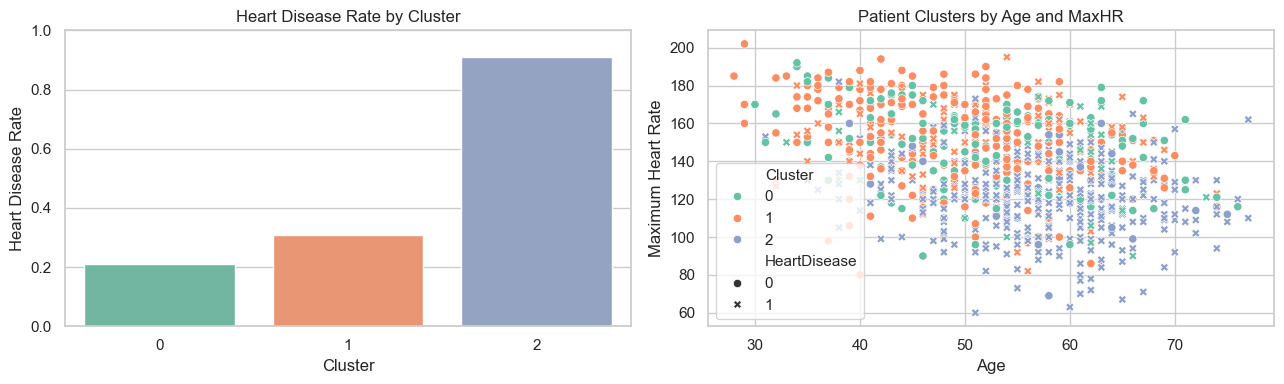

In [364]:
# Visualize the cluster summaries.
# The bar chart shows how common heart disease is in each patient archetype.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=cluster_summary.reset_index(), x="Cluster", y="HeartDiseaseRate", ax=axes[0], palette="Set2")
axes[0].set_title("Heart Disease Rate by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Heart Disease Rate")
axes[0].set_ylim(0, 1)

sns.scatterplot(data=df, x="Age", y="MaxHR", hue="Cluster", style="HeartDisease", palette="Set2", ax=axes[1])
axes[1].set_title("Patient Clusters by Age and MaxHR")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Maximum Heart Rate")

plt.tight_layout()
fig.savefig(outputs_dir / "cluster_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [365]:
# Interpret each cluster as a patient archetype in simple language.
from IPython.display import Markdown

interpretation_lines = ["### Patient Archetype Interpretations"]

for cluster_id in sorted(df["Cluster"].unique()):
    row = cluster_summary.loc[cluster_id]
    modes = cluster_category_modes[cluster_category_modes["Cluster"] == cluster_id].iloc[0]

    if row["HeartDiseaseRate"] >= 0.70:
        risk_label = "higher-risk"
    elif row["HeartDiseaseRate"] >= 0.45:
        risk_label = "moderate-risk"
    else:
        risk_label = "lower-risk"

    interpretation_lines.append(
        f"**Cluster {cluster_id}: {risk_label.title()} patient archetype.** "
        f"This group has an average age of **{row['Age']:.1f}**, average maximum heart rate of **{row['MaxHR']:.1f}**, "
        f"average Oldpeak of **{row['Oldpeak']:.2f}**, and a heart disease rate of **{row['HeartDiseaseRate']:.0%}**. "
        f"The most common profile is Sex = **{modes['Sex']}**, ChestPainType = **{modes['ChestPainType']}**, "
        f"ExerciseAngina = **{modes['ExerciseAngina']}**, and ST_Slope = **{modes['ST_Slope']}**. "
        f"In plain language, this cluster represents patients who may need a **{risk_label} level of attention** based on their shared clinical pattern."
    )

display(Markdown("\n\n".join(interpretation_lines)))

### Patient Archetype Interpretations

**Cluster 0: Lower-Risk patient archetype.** This group has an average age of **52.2**, average maximum heart rate of **147.6**, average Oldpeak of **0.57**, and a heart disease rate of **21%**. The most common profile is Sex = **F**, ChestPainType = **ATA**, ExerciseAngina = **N**, and ST_Slope = **Up**. In plain language, this cluster represents patients who may need a **lower-risk level of attention** based on their shared clinical pattern.

**Cluster 1: Lower-Risk patient archetype.** This group has an average age of **50.1**, average maximum heart rate of **149.7**, average Oldpeak of **0.39**, and a heart disease rate of **31%**. The most common profile is Sex = **M**, ChestPainType = **ASY**, ExerciseAngina = **N**, and ST_Slope = **Up**. In plain language, this cluster represents patients who may need a **lower-risk level of attention** based on their shared clinical pattern.

**Cluster 2: Higher-Risk patient archetype.** This group has an average age of **56.9**, average maximum heart rate of **121.2**, average Oldpeak of **1.45**, and a heart disease rate of **91%**. The most common profile is Sex = **M**, ChestPainType = **ASY**, ExerciseAngina = **Y**, and ST_Slope = **Flat**. In plain language, this cluster represents patients who may need a **higher-risk level of attention** based on their shared clinical pattern.

## 7. Decision Tree Classification

A Decision Tree is a supervised model that creates a tree of questions to classify patients. It is useful for doctors because it is **interpretable**: the model can show which patient features were used at each decision point, such as ST slope, chest pain type, exercise angina, age, or maximum heart rate.

Unlike a black-box model, a Decision Tree can be visualized and converted into readable if-then rules. This makes it easier to explain why a patient was classified as higher or lower risk for heart disease.

In [366]:
# Train a Decision Tree classifier using the prepared train-test split.
# max_depth=4 keeps the tree easier to read and helps reduce overfitting.
dt_feature_names = get_feature_names(preprocessor)

decision_tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
decision_tree_model.fit(X_train_prepared, y_train)

# Predict HeartDisease on the test set.
dt_predictions = decision_tree_model.predict(X_test_prepared)
dt_probabilities = decision_tree_model.predict_proba(X_test_prepared)[:, 1]

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


,Metric,Score
0,Accuracy,0.804
1,Precision,0.830
2,Recall,0.814
3,F1-score,0.822


Decision Tree Classification Report
                  precision    recall  f1-score   support

No Heart Disease       0.77      0.79      0.78        82
   Heart Disease       0.83      0.81      0.82       102

        accuracy                           0.80       184
       macro avg       0.80      0.80      0.80       184
    weighted avg       0.80      0.80      0.80       184



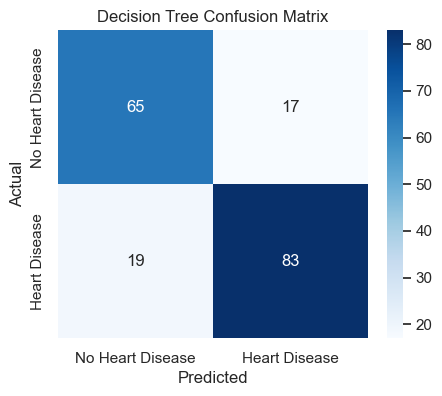

In [367]:
# Evaluate the Decision Tree using common classification metrics.
decision_tree_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        accuracy_score(y_test, dt_predictions),
        precision_score(y_test, dt_predictions),
        recall_score(y_test, dt_predictions),
        f1_score(y_test, dt_predictions)
    ]
})

display(decision_tree_metrics.round(3))

print("Decision Tree Classification Report")
print(classification_report(y_test, dt_predictions, target_names=["No Heart Disease", "Heart Disease"]))

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, dt_predictions),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(outputs_dir / "decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

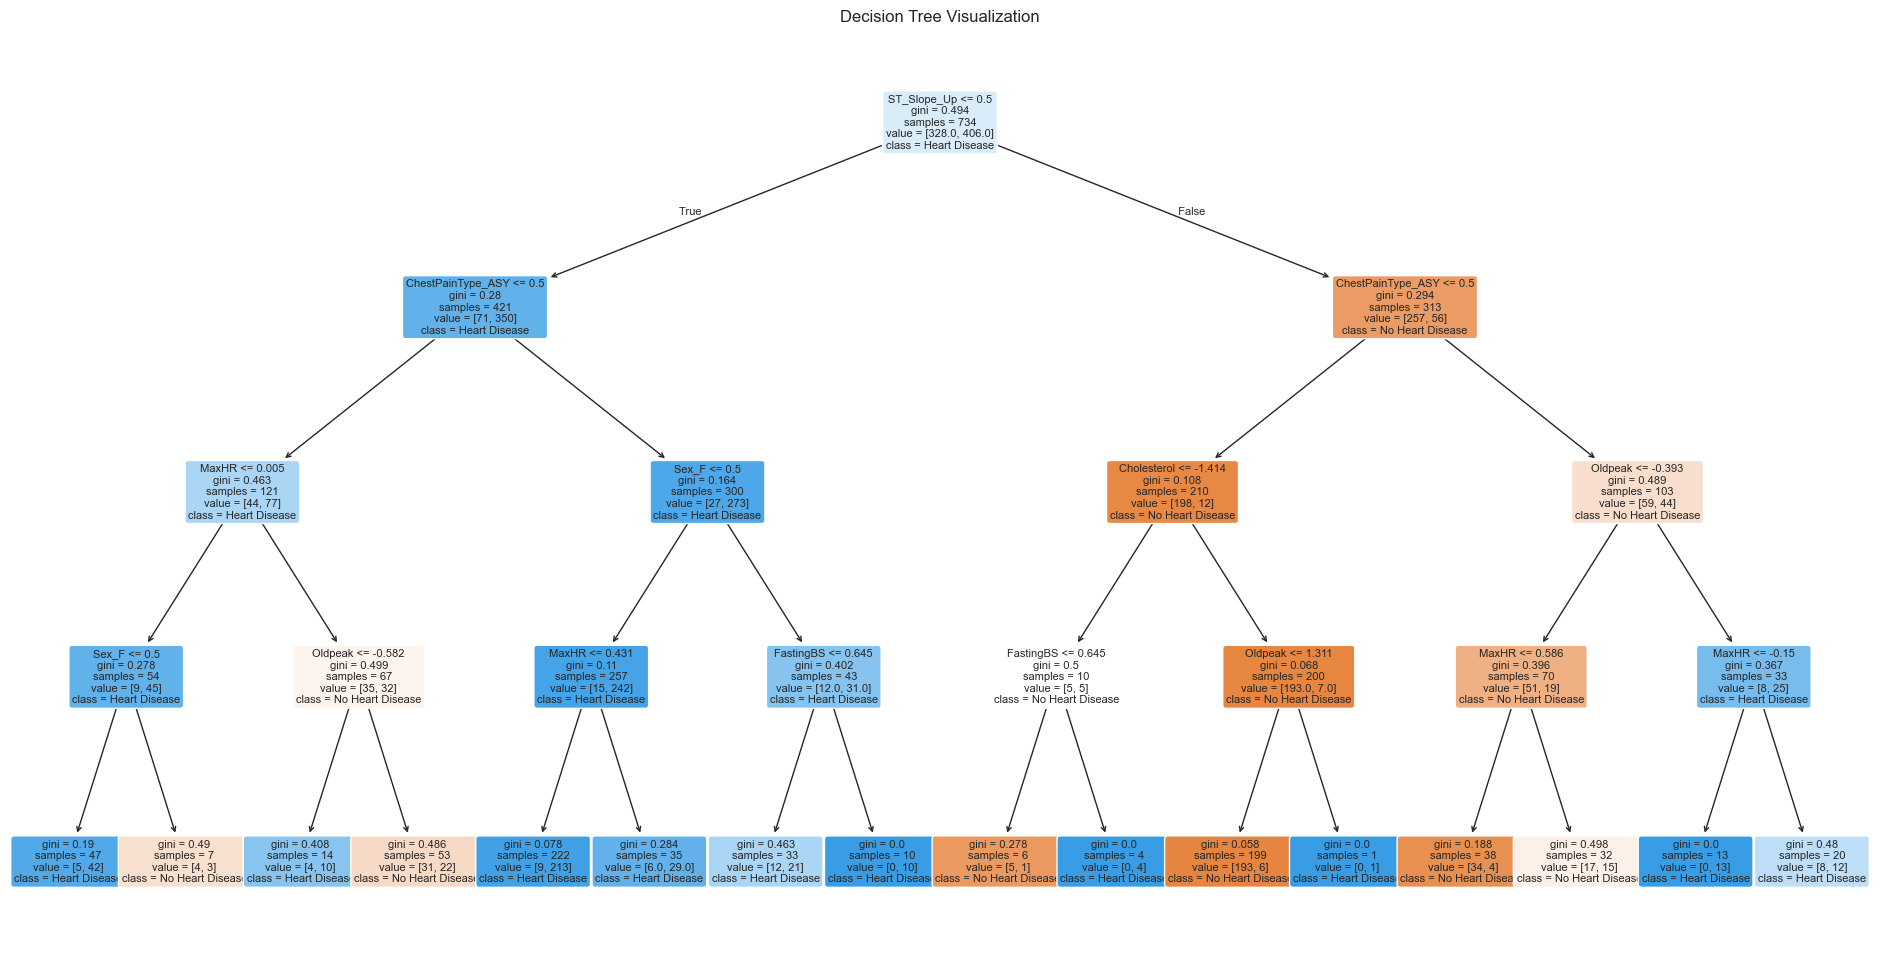

In [368]:
# Visualize the trained Decision Tree.
plt.figure(figsize=(24, 12))
plot_tree(
    decision_tree_model,
    feature_names=dt_feature_names,
    class_names=["No Heart Disease", "Heart Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.savefig(outputs_dir / "decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [369]:
# Extract readable decision rules from the trained tree.
# These if-then rules explain the model's decision path in text form.
decision_tree_rules = export_text(
    decision_tree_model,
    feature_names=list(dt_feature_names),
    decimals=2
)

print(decision_tree_rules)

|--- ST_Slope_Up <= 0.50
|   |--- ChestPainType_ASY <= 0.50
|   |   |--- MaxHR <= 0.00
|   |   |   |--- Sex_F <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Sex_F >  0.50
|   |   |   |   |--- class: 0
|   |   |--- MaxHR >  0.00
|   |   |   |--- Oldpeak <= -0.58
|   |   |   |   |--- class: 1
|   |   |   |--- Oldpeak >  -0.58
|   |   |   |   |--- class: 0
|   |--- ChestPainType_ASY >  0.50
|   |   |--- Sex_F <= 0.50
|   |   |   |--- MaxHR <= 0.43
|   |   |   |   |--- class: 1
|   |   |   |--- MaxHR >  0.43
|   |   |   |   |--- class: 1
|   |   |--- Sex_F >  0.50
|   |   |   |--- FastingBS <= 0.65
|   |   |   |   |--- class: 1
|   |   |   |--- FastingBS >  0.65
|   |   |   |   |--- class: 1
|--- ST_Slope_Up >  0.50
|   |--- ChestPainType_ASY <= 0.50
|   |   |--- Cholesterol <= -1.41
|   |   |   |--- FastingBS <= 0.65
|   |   |   |   |--- class: 0
|   |   |   |--- FastingBS >  0.65
|   |   |   |   |--- class: 1
|   |   |--- Cholesterol >  -1.41
|   |   |   |--- Oldpeak <= 1.31
|   

### Why This Model Is Useful for Doctors

The Decision Tree is useful in a clinical setting because it is easy to explain. A doctor can follow the tree from top to bottom and see which patient characteristics influenced the prediction. This helps connect the model output to familiar clinical ideas, such as exercise angina, ST slope, chest pain type, age, and maximum heart rate.

Because the tree produces readable rules, it can support patient risk screening and discussion. However, it should only assist clinical judgment. A prediction from this notebook is not a medical diagnosis.

## 8. Random Forest Classification

A Random Forest is an ensemble model made of many decision trees. It often performs better than a single Decision Tree because it combines several trees and reduces overfitting.

In this section, we train the Random Forest using the same train-test split and prepared encoded/scaled features used by the Decision Tree.

In [370]:
# Train a Random Forest classifier using the same prepared train-test split.
# n_estimators=100 means the forest builds 100 decision trees.
rf_feature_names = get_feature_names(preprocessor)

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_prepared, y_train)

# Predict HeartDisease on the test set.
rf_predictions = random_forest_model.predict(X_test_prepared)
rf_probabilities = random_forest_model.predict_proba(X_test_prepared)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


,Metric,Score
0,Accuracy,0.891
1,Precision,0.894
2,Recall,0.912
3,F1-score,0.903


Random Forest Classification Report
                  precision    recall  f1-score   support

No Heart Disease       0.89      0.87      0.88        82
   Heart Disease       0.89      0.91      0.90       102

        accuracy                           0.89       184
       macro avg       0.89      0.89      0.89       184
    weighted avg       0.89      0.89      0.89       184



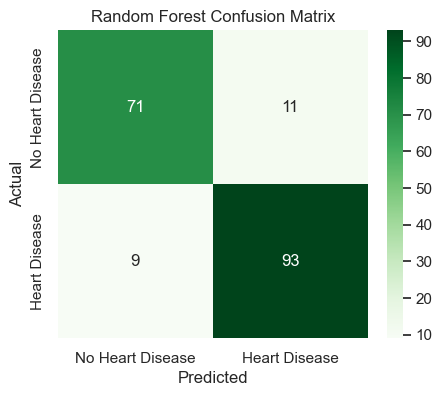

In [371]:
# Evaluate the Random Forest using common classification metrics.
random_forest_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        accuracy_score(y_test, rf_predictions),
        precision_score(y_test, rf_predictions),
        recall_score(y_test, rf_predictions),
        f1_score(y_test, rf_predictions)
    ]
})

display(random_forest_metrics.round(3))

print("Random Forest Classification Report")
print(classification_report(y_test, rf_predictions, target_names=["No Heart Disease", "Heart Disease"]))

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, rf_predictions),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(outputs_dir / "random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

,feature,importance
19,ST_Slope_Up,0.159
5,Oldpeak,0.101
2,Cholesterol,0.093
18,ST_Slope_Flat,0.093
4,MaxHR,0.092
8,ChestPainType_ASY,0.086
0,Age,0.072
1,RestingBP,0.066
15,ExerciseAngina_N,0.060
16,ExerciseAngina_Y,0.045


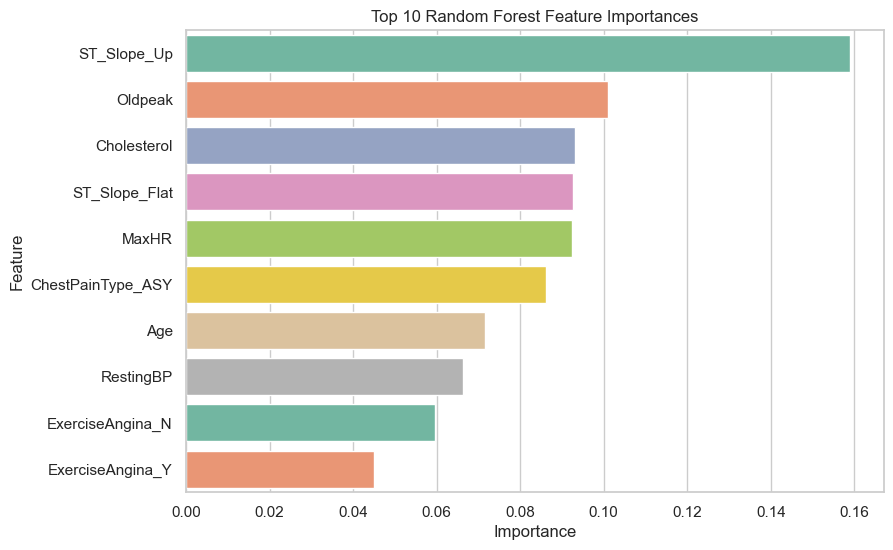

In [372]:
# Feature importance helps identify which variables were most useful to the Random Forest.
feature_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": random_forest_model.feature_importances_
}).sort_values("importance", ascending=False)

top_10_rf_features = feature_importance.head(10)
display(top_10_rf_features)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_10_rf_features, x="importance", y="feature", palette="Set2")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig(outputs_dir / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### Random Forest Feature Importance Interpretation

The feature importance chart shows which variables contributed most to the Random Forest's heart disease predictions. Features near the top had more influence across the 100 trees in the model.

In this dataset, the most important features are commonly related to clinical exercise response and symptoms, such as `ST_Slope`, `Oldpeak`, `MaxHR`, `ExerciseAngina`, and `ChestPainType`. In simple clinical language, this means the model is paying close attention to how the heart responds during exercise, whether chest pain symptoms are present, and whether the patient's heart rate patterns look concerning.

Feature importance does not prove medical causation, but it helps explain which patient characteristics the model relied on most when predicting heart disease.

## 9. Model Evaluation and Comparison

We compare Decision Tree and Random Forest using accuracy, precision, recall, F1-score, and confusion matrices.

For heart disease prediction, **recall is especially important** because it measures how many real heart disease cases the model successfully catches. In a hospital setting, missing a patient who actually has heart disease can delay treatment and create serious risk.

In [373]:
# Build a comparison table for both classification models.
# Recall is especially important for heart disease screening because false negatives are dangerous.
model_results = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, dt_predictions),
        "Precision": precision_score(y_test, dt_predictions),
        "Recall": recall_score(y_test, dt_predictions),
        "F1-score": f1_score(y_test, dt_predictions)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_predictions),
        "Precision": precision_score(y_test, rf_predictions),
        "Recall": recall_score(y_test, rf_predictions),
        "F1-score": f1_score(y_test, rf_predictions)
    }
])

model_results = model_results.sort_values(["Recall", "F1-score", "Accuracy"], ascending=False)
display(model_results.round(3))

,Model,Accuracy,Precision,Recall,F1-score
1,Random Forest,0.891,0.894,0.912,0.903
0,Decision Tree,0.804,0.830,0.814,0.822


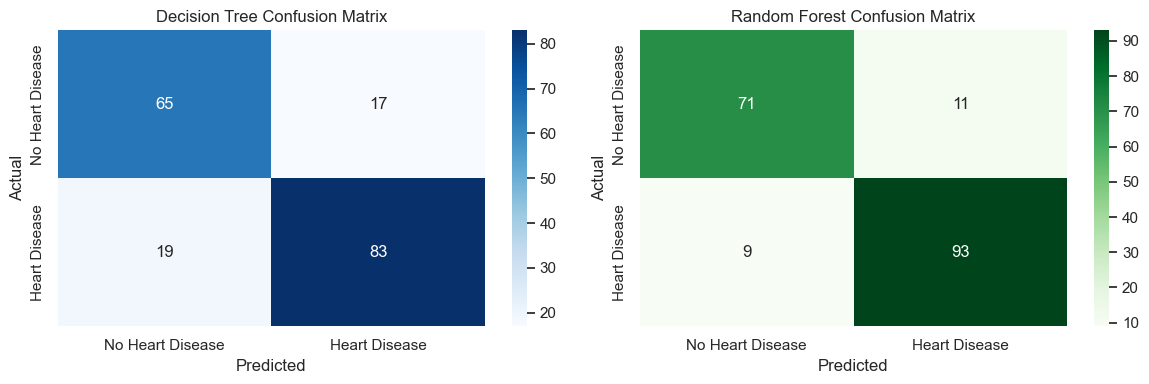

In [374]:
# Compare confusion matrices side by side.
# Rows are actual classes; columns are predicted classes.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dt_cm = confusion_matrix(y_test, dt_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)
class_labels = ["No Heart Disease", "Heart Disease"]

sns.heatmap(dt_cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title("Decision Tree Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens", xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title("Random Forest Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [375]:
# Recommend a model for hospital deployment.
# The ranking prioritizes recall, then F1-score, then accuracy.
best_model_row = model_results.iloc[0]
recommended_model = best_model_row["Model"]

print(f"Recommended model for hospital deployment: {recommended_model}")
display(best_model_row.to_frame(name="Value"))

Recommended model for hospital deployment: Random Forest


,Value
Model,Random Forest
Accuracy,0.891
Precision,0.894
Recall,0.912
F1-score,0.903


### Hospital-Focused Interpretation

**Recall matters most in heart disease prediction** because it tells us how well the model finds patients who truly have heart disease. A model with higher recall misses fewer real heart disease cases.

A **false negative** means the model predicts `No Heart Disease` even though the patient actually has heart disease. In a hospital, this is dangerous because the patient may be sent home, receive delayed treatment, or miss additional testing.

A **false positive** means the model predicts `Heart Disease` even though the patient does not actually have heart disease. This can lead to extra tests, patient anxiety, and additional hospital cost, but it is usually less dangerous than missing a real heart disease case.

For hospital deployment, the recommended model should have strong recall, good overall performance, and enough interpretability for clinicians. If the Random Forest has the highest recall and F1-score, it is the stronger predictive model. However, the Decision Tree remains valuable because it is easier to explain. A practical hospital workflow could use the Random Forest for screening performance and the Decision Tree rules to help explain the prediction to doctors.

## 10. Final Clinical Insights and Recommendation

This section summarizes the most important findings from the data mining process. These statements should be updated after running the notebook and reviewing the actual outputs.

In [376]:
# Create a small summary of data-driven signals that can support the final written interpretation.
heart_disease_rate = df["HeartDisease"].mean() * 100
top_rf_features = feature_importance.head(5)["feature"].tolist()

print(f"Overall heart disease rate in the dataset: {heart_disease_rate:.2f}%")
print("Top Random Forest features:")
for feature in top_rf_features:
    print(f"- {feature}")

print("\nCluster heart disease rates:")
display(cluster_summary[["PatientCount", "HeartDiseaseRate"]])

Overall heart disease rate in the dataset: 55.34%
Top Random Forest features:
- ST_Slope_Up
- Oldpeak
- Cholesterol
- ST_Slope_Flat
- MaxHR

Cluster heart disease rates:


,PatientCount,HeartDiseaseRate
Cluster,,
0,179,0.210
1,337,0.310
2,402,0.910


### Final Insights

After running the analysis, the project should support several clinical-style insights:

1. **Patient risk is not explained by one variable alone.** Heart disease patterns are better understood by combining symptoms, exercise response, heart rate, age, and ECG-related information.
2. **Association rules can highlight common risk profiles.** Rules with high lift and confidence may reveal combinations such as specific chest pain types, exercise-induced angina, ST slope patterns, or older age groups that appear more often with heart disease.
3. **K-Means clustering helps describe patient archetypes.** The clusters can separate patients into groups with different average ages, heart rates, Oldpeak values, and heart disease rates.
4. **Random Forest often provides stronger predictive performance.** Compared with a single Decision Tree, Random Forest usually gives more stable results because it combines many trees.
5. **Decision Trees remain useful for explanation.** Even if the Random Forest performs better, the Decision Tree visualization is easier to explain to beginners and non-technical readers.

### Recommendation

For this educational project, the recommended final model is the model with the better F1-score and ROC-AUC after running the evaluation cells. If Random Forest performs best, it should be used for prediction, while the Decision Tree and association rules should be used to explain important patterns in a more interpretable way.

In a real clinical setting, a model like this should only support decision-making. It should be validated with larger and more diverse patient data, reviewed by healthcare professionals, and combined with proper clinical assessment.